In [1]:
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)



shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
df = pd.read_csv('weld_inspection.csv')
y = df['defect']; X = df.drop(columns='defect')
num = X.select_dtypes('number').columns.tolist(); cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print('shape:', df.shape, '| defect rate:', round(y.mean(), 3))
df.head(3)


shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


In [5]:
# -----------------------------------------------------------
# 🔹 1A. A SINGLE DECISION TREE
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=4, random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')


test F1 (depth 4): 0.143
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


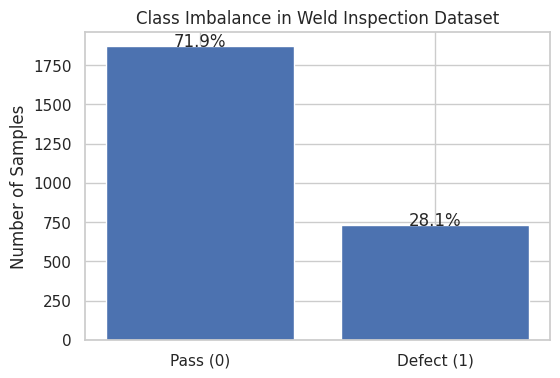

In [15]:
counts = df['defect'].value_counts()
percentages = df['defect'].value_counts(normalize=True)*100

plt.figure(figsize=(6,4))

bars = plt.bar(
    ['Pass (0)', 'Defect (1)'],
    counts
)

for i, bar in enumerate(bars):
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{percentages.iloc[i]:.1f}%',
        ha='center'
    )

plt.title("Class Imbalance in Weld Inspection Dataset")
plt.ylabel("Number of Samples")

plt.show()

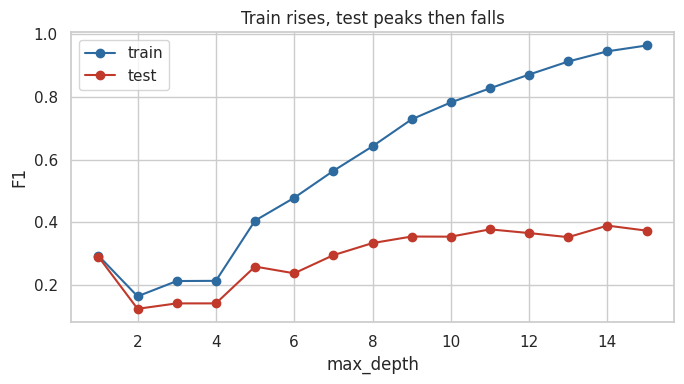

In [6]:
# -----------------------------------------------------------
# 🔹 1B. TRAIN vs TEST F1 ACROSS DEPTH (the overfitting curve)
# -----------------------------------------------------------
depths = range(1, 16); tr, te = [], []
for d in depths:
    m = Pipeline([('prep', pre), ('clf', DecisionTreeClassifier(max_depth=d, random_state=0))]).fit(X_train, y_train)
    tr.append(f1_score(y_train, m.predict(X_train)))
    te.append(f1_score(y_test, m.predict(X_test)))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(depths), tr, 'o-', label='train', color='#2D6A9F')
ax.plot(list(depths), te, 'o-', label='test', color='#C0392B')
ax.set_xlabel('max_depth'); ax.set_ylabel('F1'); ax.set_title('Train rises, test peaks then falls')
ax.legend(); plt.tight_layout(); plt.show()


Test F1 (red line) reaches its highest value at max_depth = 14 (around 0.39).
After that, at depth 15, the test F1 drops slightly.
Therefore, the best depth is 14.

In [7]:
# Best depth from the curve
best_depth = 14

# The widening gap between train and test F1 at larger depths
# indicates overfitting. The tree is learning training-set noise
# and memorizing examples, so training performance keeps improving
# while test performance stops improving or decreases.

best_model = Pipeline([
    ('prep', pre),
    ('model', DecisionTreeClassifier(
        max_depth=best_depth,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Test F1:", round(f1_score(y_test, y_pred), 4))

Test F1: 0.3945


# Class balanced data
```



In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
tree = Pipeline([('prep', pre),('clf', DecisionTreeClassifier(max_depth=4,class_weight='balanced', random_state=0))])
tree.fit(X_train, y_train)
print('test F1 (depth 4):', round(f1_score(y_test, tree.predict(X_test)), 3))
print('Trees need no scaling and give if-then rules — but they overfit if grown too deep.')


test F1 (depth 4): 0.43
Trees need no scaling and give if-then rules — but they overfit if grown too deep.


In [11]:
best_model = Pipeline([
    ('prep', pre),
    ('model', DecisionTreeClassifier(
        max_depth=best_depth,class_weight='balanced',random_state=42 ))])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Test F1:", round(f1_score(y_test, y_pred), 4))

Test F1: 0.3202


In [12]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
smote_model = Pipeline([
    ('prep', pre),
    ('smote', SMOTE(random_state=42)),
    ('tree', DecisionTreeClassifier(
        max_depth=14,
        random_state=42
    ))
])

smote_model.fit(X_train, y_train)

pred_smote = smote_model.predict(X_test)

print("SMOTE F1:",
      round(f1_score(y_test, pred_smote), 4))

SMOTE F1: 0.3351


In [13]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import ADASYN
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

adasyn_model = Pipeline([
    ('prep', pre),
    ('adasyn', ADASYN(random_state=42)),
    ('tree', DecisionTreeClassifier(
        max_depth=14,
        random_state=42
    ))
])

adasyn_model.fit(X_train, y_train)

pred_adasyn = adasyn_model.predict(X_test)

print("ADASYN F1:",
      round(f1_score(y_test, pred_adasyn), 4))

ADASYN F1: 0.3548


Before SMOTE
defect
0    1402
1     548
Name: count, dtype: int64

After SMOTE
defect
0    1402
1    1402
Name: count, dtype: int64


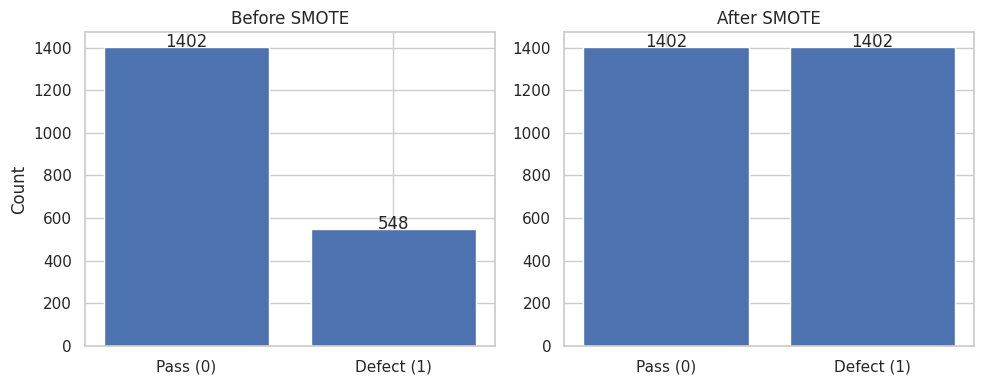

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

# -----------------------------
# 1. Preprocess the training data
# -----------------------------
X_train_pre = pre.fit_transform(X_train)

# -----------------------------
# 2. Apply SMOTE
# -----------------------------
smote = SMOTE(random_state=42)

X_sm, y_sm = smote.fit_resample(
    X_train_pre,
    y_train
)

# -----------------------------
# 3. Print counts
# -----------------------------
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_sm).value_counts())

# -----------------------------
# 4. Plot before and after
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# Before SMOTE
before_counts = y_train.value_counts().sort_index()

ax[0].bar(
    ['Pass (0)', 'Defect (1)'],
    before_counts.values
)

ax[0].set_title("Before SMOTE")
ax[0].set_ylabel("Count")

for i, v in enumerate(before_counts.values):
    ax[0].text(i, v, str(v), ha='center')

# After SMOTE
after_counts = pd.Series(y_sm).value_counts().sort_index()

ax[1].bar(
    ['Pass (0)', 'Defect (1)'],
    after_counts.values
)

ax[1].set_title("After SMOTE")

for i, v in enumerate(after_counts.values):
    ax[1].text(i, v, str(v), ha='center')

plt.tight_layout()
plt.show()

| Method                      | What It Does                                                | New Samples Created? | Data Size Changes? | Best For                            | Advantages                      | Disadvantages                  |
| --------------------------- | ----------------------------------------------------------- | -------------------- | ------------------ | ----------------------------------- | ------------------------------- | ------------------------------ |
| **No Handling**             | Uses original data                                          | ❌ No                 | ❌ No               | Balanced datasets                   | Simple                          | Poor minority-class detection  |
| **class_weight='balanced'** | Increases importance of minority class during training      | ❌ No                 | ❌ No               | Logistic Regression, Decision Trees | Easy to apply, no extra data    | May increase false positives   |
| **Random Oversampling**     | Copies minority-class samples                               | ✅ Yes (duplicates)   | ✅ Increases        | Small datasets                      | Simple                          | Can overfit                    |
| **Random Undersampling**    | Removes majority-class samples                              | ❌ No                 | ✅ Decreases        | Very large datasets                 | Fast                            | Loses information              |
| **SMOTE**                   | Creates synthetic minority samples between existing samples | ✅ Yes                | ✅ Increases        | Most ML models                      | Popular, improves Recall/F1     | Can create unrealistic samples |
| **ADASYN**                  | Creates more synthetic samples in difficult regions         | ✅ Yes                | ✅ Increases        | Complex decision boundaries         | Focuses on hard cases           | More sensitive to noise        |
| **Threshold Tuning**        | Changes decision threshold (e.g., 0.5 → 0.3)                | ❌ No                 | ❌ No               | Logistic Regression, XGBoost        | Improves Recall                 | May reduce Precision           |
| **Balanced Random Forest**  | Balances data for each tree                                 | ✅ Internally         | ❌ No               | Random Forest                       | Handles imbalance automatically | More complex                   |


| Technique                 | Numerical Data | Categorical Data | Mixed Data (Numerical + Categorical) |
| ------------------------- | -------------- | ---------------- | ------------------------------------ |
| `class_weight='balanced'` | ✅ Yes          | ✅ Yes            | ✅ Yes                                |
| Random Oversampling       | ✅ Yes          | ✅ Yes            | ✅ Yes                                |
| Random Undersampling      | ✅ Yes          | ✅ Yes            | ✅ Yes                                |
| SMOTE                     | ✅ Yes          | ❌ No (directly)  | ⚠️ After Encoding                    |
| ADASYN                    | ✅ Yes          | ❌ No (directly)  | ⚠️ After Encoding                    |
| Threshold Tuning          | ✅ Yes          | ✅ Yes            | ✅ Yes                                |


In [22]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='f1', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}
best CV F1: 0.33
tuned test F1: 0.347


In [23]:
# -----------------------------------------------------------
# 🔹 4A. GRID-SEARCH GRADIENT BOOSTING ON F1
# -----------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_pipe = Pipeline([('prep', pre), ('clf', GradientBoostingClassifier(random_state=0))])
grid = {'clf__max_depth': [2, 3], 'clf__n_estimators': [200, 400],
        'clf__learning_rate': [0.05, 0.1]}
gs = GridSearchCV(gb_pipe, grid, cv=4, scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)
print('best params:', gs.best_params_)
print('best CV F1:', round(gs.best_score_, 3))
best = gs.best_estimator_
print('tuned test F1:', round(f1_score(y_test, best.predict(X_test)), 3))

best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 400}
best CV F1: 0.663
tuned test F1: 0.323


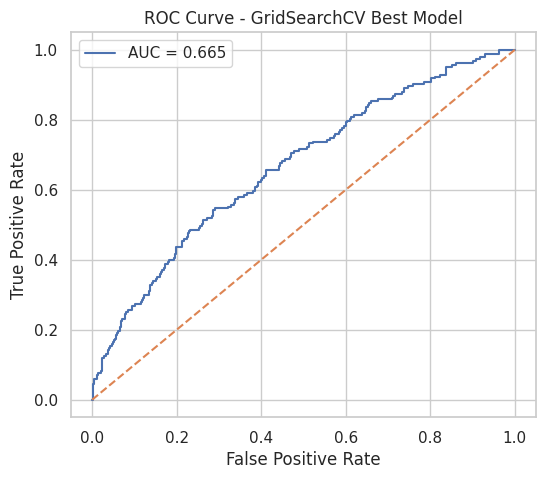

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# get best model
best = gs.best_estimator_

# probability scores (important for ROC)
y_prob = best.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GridSearchCV Best Model")
plt.legend()

plt.show()